# Evaluation
**Proyek:** Analisis Sentimen Ulasan Shopee — Bummi Tani  
**Tujuan:** Mengevaluasi performa ketiga model (SVM, Naïve Bayes, KNN) pada data uji menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

---

## Import Library

In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid')

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print('Library berhasil diimport.')

Library berhasil diimport.


## Load Model dan Data Uji

In [2]:
PREP_DIR    = '../3-Data-Preparation'
MODEL_DIR   = '../4-Modeling'
OUTPUT_DIR  = '.'

def load_artifact(filename, base_dir):
    path = os.path.join(base_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f'❌ File tidak ditemukan: {path}')
    obj = joblib.load(path)
    print(f'  ✅ Dimuat: {path}')
    return obj

print('Memuat data uji')
X_test = load_artifact('X_test.pkl', PREP_DIR)
y_test = load_artifact('y_test.pkl', PREP_DIR)

print('\nMemuat model')
svm_model = load_artifact('svm_model.pkl', MODEL_DIR)
nb_model  = load_artifact('nb_model.pkl', MODEL_DIR)
knn_model = load_artifact('knn_model.pkl', MODEL_DIR)

print(f'\nSemua artefak berhasil dimuat.')
print(f'   → X_test : {X_test.shape}')
print(f'   → y_test : {y_test.shape} | Positif={y_test.sum()}, Negatif={(y_test==0).sum()}')

Memuat data uji
  ✅ Dimuat: ../3-Data-Preparation/X_test.pkl
  ✅ Dimuat: ../3-Data-Preparation/y_test.pkl

Memuat model
  ✅ Dimuat: ../4-Modeling/svm_model.pkl
  ✅ Dimuat: ../4-Modeling/nb_model.pkl
  ✅ Dimuat: ../4-Modeling/knn_model.pkl

Semua artefak berhasil dimuat.
   → X_test : (97, 801)
   → y_test : (97,) | Positif=85, Negatif=12


## Prediksi pada Data Uji

In [3]:
# SVM Prediction
y_pred_svm = svm_model.predict(X_test)
print(f'SVM    : prediksi selesai')

# Naïve Bayes Prediction (pastikan non-negatif)
X_test_mnb = X_test.copy()
if sp.issparse(X_test_mnb):
    X_test_mnb.data = np.abs(X_test_mnb.data)
y_pred_nb = nb_model.predict(X_test_mnb)
print(f'NB     : prediksi selesai')

# KNN Prediction
y_pred_knn = knn_model.predict(X_test)
print(f'KNN    : prediksi selesai')

SVM    : prediksi selesai
NB     : prediksi selesai
KNN    : prediksi selesai


## Confusion Matrix

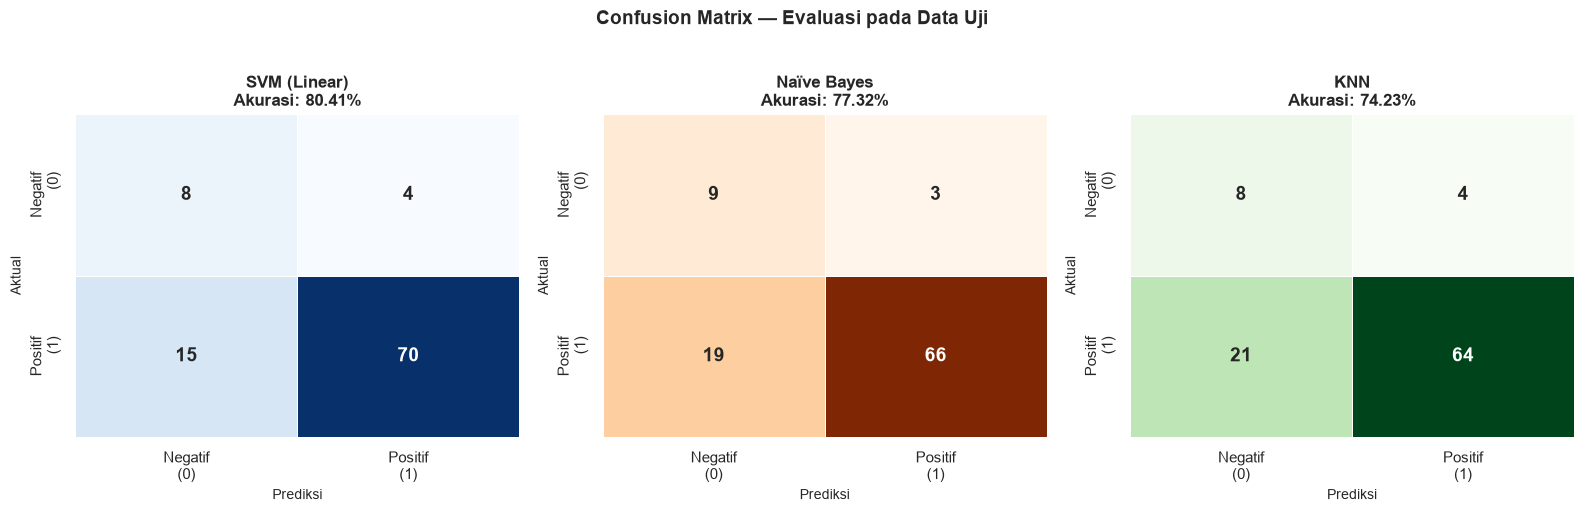

In [4]:
def plot_confusion_matrix(ax, y_true, y_pred, model_name, color):
    """Menggambar Confusion Matrix dengan heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    labels = ['Negatif\n(0)', 'Positif\n(1)']
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color,
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar=False, annot_kws={'size': 14, 'weight': 'bold'}
    )
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{model_name}\nAkurasi: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)
    return cm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cm_svm = plot_confusion_matrix(axes[0], y_test, y_pred_svm, 'SVM (Linear)', 'Blues')
cm_nb  = plot_confusion_matrix(axes[1], y_test, y_pred_nb,  'Naïve Bayes',  'Oranges')
cm_knn = plot_confusion_matrix(axes[2], y_test, y_pred_knn, 'KNN',           'Greens')

plt.suptitle('Confusion Matrix — Evaluasi pada Data Uji', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Laporan Klasifikasi Detail

In [5]:
target_names = ['Negatif (0)', 'Positif (1)']

models_info = [
    ('SVM (Kernel Linear)', y_pred_svm),
    ('Multinomial Naïve Bayes', y_pred_nb),
    ('KNN', y_pred_knn),
]

for model_name, y_pred in models_info:
    print(f'{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(classification_report(y_test, y_pred, target_names=target_names))
    print()

  SVM (Kernel Linear)
              precision    recall  f1-score   support

 Negatif (0)       0.35      0.67      0.46        12
 Positif (1)       0.95      0.82      0.88        85

    accuracy                           0.80        97
   macro avg       0.65      0.75      0.67        97
weighted avg       0.87      0.80      0.83        97


  Multinomial Naïve Bayes
              precision    recall  f1-score   support

 Negatif (0)       0.32      0.75      0.45        12
 Positif (1)       0.96      0.78      0.86        85

    accuracy                           0.77        97
   macro avg       0.64      0.76      0.65        97
weighted avg       0.88      0.77      0.81        97


  KNN
              precision    recall  f1-score   support

 Negatif (0)       0.28      0.67      0.39        12
 Positif (1)       0.94      0.75      0.84        85

    accuracy                           0.74        97
   macro avg       0.61      0.71      0.61        97
weighted avg      

## Tabel Komparasi Performa

In [6]:
def get_metrics(y_true, y_pred):
    """Hitung semua metrik evaluasi."""
    avg = 'weighted'
    return {
        'Accuracy (%)':  round(accuracy_score(y_true, y_pred) * 100, 4),
        'Precision (%)': round(precision_score(y_true, y_pred, average=avg, zero_division=0) * 100, 4),
        'Recall (%)':    round(recall_score(y_true, y_pred, average=avg, zero_division=0) * 100, 4),
        'F1-Score (%)':  round(f1_score(y_true, y_pred, average=avg, zero_division=0) * 100, 4),
    }

# Buat tabel komparasi
eval_results = pd.DataFrame([
    {'Model': 'SVM (Kernel Linear)',       **get_metrics(y_test, y_pred_svm)},
    {'Model': 'Multinomial Naïve Bayes',   **get_metrics(y_test, y_pred_nb)},
    {'Model': 'KNN',                        **get_metrics(y_test, y_pred_knn)},
])

eval_results_sorted = eval_results.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
eval_results_sorted.index = eval_results_sorted.index + 1  # Mulai dari 1

print('='*65)
print('  TABEL KOMPARASI PERFORMA ALGORITMA (Data Uji)')
print('='*65)
print(eval_results_sorted.to_string())
print(f'\nModel Terbaik: {eval_results_sorted.iloc[0]["Model"]} — Accuracy: {eval_results_sorted.iloc[0]["Accuracy (%)"]:.2f}%')

  TABEL KOMPARASI PERFORMA ALGORITMA (Data Uji)
                     Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
1      SVM (Kernel Linear)       80.4124        87.1952     80.4124       82.8129
2  Multinomial Naïve Bayes       77.3196        87.7954     77.3196       80.6775
3                      KNN       74.2268        85.8870     74.2268       78.1382

Model Terbaik: SVM (Kernel Linear) — Accuracy: 80.41%


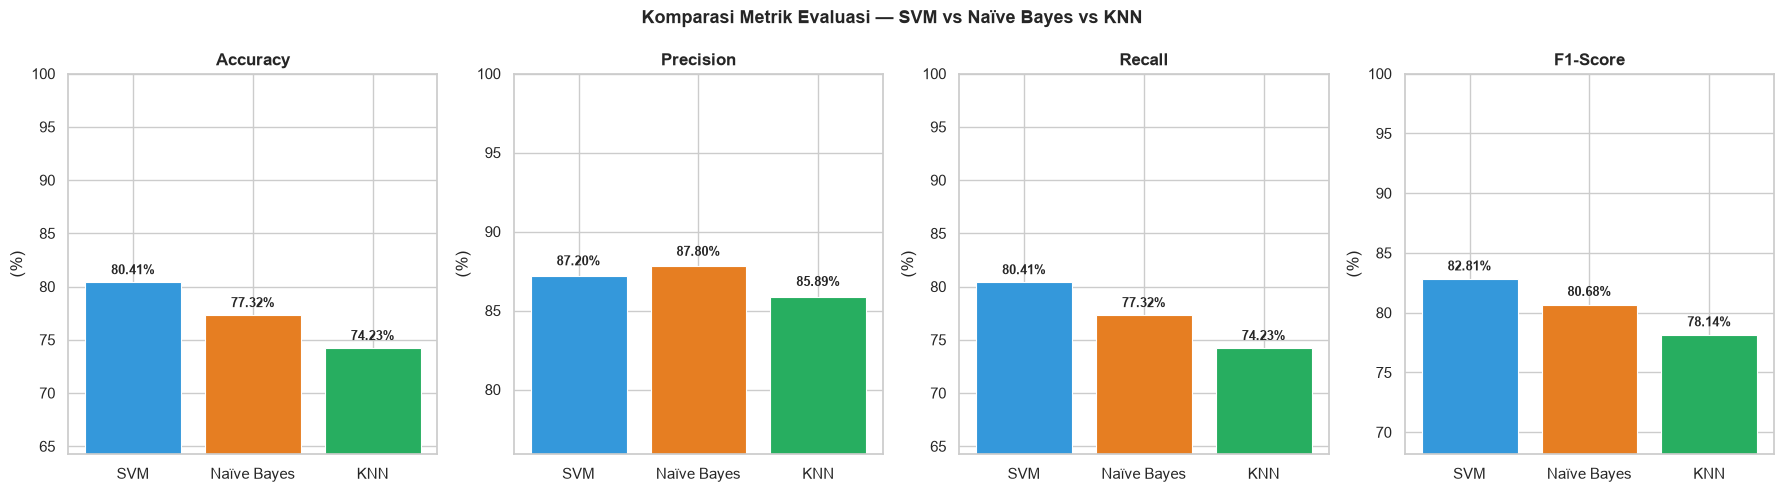

In [7]:
# Visualisasi komparasi metrik
metrics_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
model_names_short = ['SVM', 'Naïve Bayes', 'KNN']
colors_model = ['#3498DB', '#E67E22', '#27AE60']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics_cols):
    values = eval_results[metric].values
    bars = ax.bar(model_names_short, values, color=colors_model, edgecolor='white', linewidth=0.8)
    ax.set_title(metric.replace(' (%)', ''), fontsize=12, fontweight='bold')
    ax.set_ylabel('(%)')
    ax.set_ylim(max(0, min(values) - 10), 100)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Komparasi Metrik Evaluasi — SVM vs Naïve Bayes vs KNN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

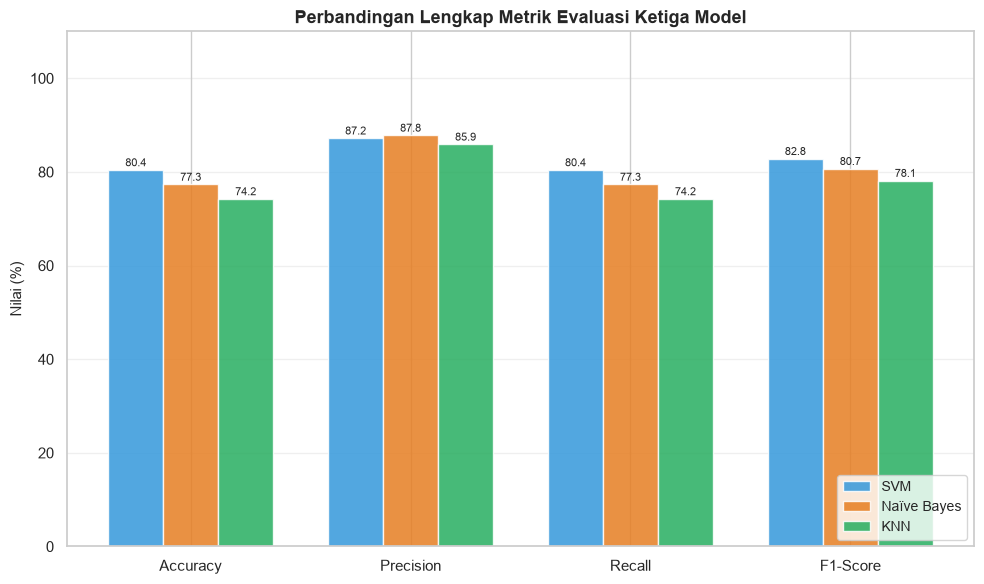

In [8]:
# Radar Chart untuk visualisasi komparasi multimetrik
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics_cols))
width = 0.25

for i, (row, color, name) in enumerate(zip(
    [eval_results.iloc[0], eval_results.iloc[1], eval_results.iloc[2]],
    colors_model, model_names_short
)):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace(' (%)', '') for m in metrics_cols], fontsize=11)
ax.set_ylabel('Nilai (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Perbandingan Lengkap Metrik Evaluasi Ketiga Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Simpan Hasil Evaluasi

In [9]:
# Simpan tabel evaluasi ke CSV
eval_path = os.path.join(OUTPUT_DIR, 'evaluation_results.csv')
eval_results_sorted.to_csv(eval_path, index=False)
print(f' Hasil evaluasi disimpan: {eval_path}')

# Simpan juga prediksi ke CSV untuk analisis lanjutan
pred_df = pd.DataFrame({
    'y_test': y_test,
    'pred_svm': y_pred_svm,
    'pred_nb': y_pred_nb,
    'pred_knn': y_pred_knn
})
pred_path = os.path.join(OUTPUT_DIR, 'predictions.csv')
pred_df.to_csv(pred_path, index=False)
print(f' Data prediksi disimpan: {pred_path}')

print(f'\n Semua hasil evaluasi tersimpan.')

 Hasil evaluasi disimpan: ./evaluation_results.csv
 Data prediksi disimpan: ./predictions.csv

 Semua hasil evaluasi tersimpan.


## Ringkasan Fase Evaluasi

| Aspek | Keterangan |
|-------|------------|
| Data Uji | 20% dari total dataset (stratified split) |
| Metrik | Accuracy, Precision (weighted), Recall (weighted), F1-Score (weighted) |
| Visualisasi | Confusion Matrix, Bar Chart komparasi metrik |

> **Model terbaik** akan digunakan dalam fase Deployment untuk simulasi prediksi ulasan baru.
> Artefak tersimpan: `evaluation_results.csv`, `predictions.csv`